In [13]:
# ===============================
# Employee Attrition Platform
# Exploratory Data Analysis (EDA)
# ===============================
import warnings
warnings.filterwarnings("ignore")

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import plotly as px

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print('Libraries imported sucessfully!')

Libraries imported sucessfully!


In [14]:
# Load DataSet
df = pd.read_csv("../data/raw/HR-Employee-Attrition.csv")

print("Dataset loaded Successfully!")

Dataset loaded Successfully!


In [15]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [16]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 1470
Columns: 35


In [17]:
df.columns.tolist()

['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'Over18',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [18]:
df.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [20]:
duplicates = df.duplicated().sum()
print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


In [21]:
missing = df.isnull().sum().sum()
print(f'Missing Values: {missing}')

Missing Values: 0


In [22]:
unique_values = df.nunique().sort_values()
unique_values

EmployeeCount                  1
Over18                         1
StandardHours                  1
Attrition                      2
OverTime                       2
PerformanceRating              2
Gender                         2
BusinessTravel                 3
Department                     3
MaritalStatus                  3
RelationshipSatisfaction       4
StockOptionLevel               4
JobSatisfaction                4
EnvironmentSatisfaction        4
JobInvolvement                 4
WorkLifeBalance                4
Education                      5
JobLevel                       5
EducationField                 6
TrainingTimesLastYear          7
JobRole                        9
NumCompaniesWorked            10
PercentSalaryHike             15
YearsSinceLastPromotion       16
YearsWithCurrManager          18
YearsInCurrentRole            19
DistanceFromHome              29
YearsAtCompany                37
TotalWorkingYears             40
Age                           43
HourlyRate

In [23]:
constant_columns = [col for col in df.columns if df[col].nunique()==1]
constant_columns

['EmployeeCount', 'Over18', 'StandardHours']

In [24]:
df.nunique().sort_values(ascending=False)

EmployeeNumber              1470
MonthlyRate                 1427
MonthlyIncome               1349
DailyRate                    886
HourlyRate                    71
Age                           43
TotalWorkingYears             40
YearsAtCompany                37
DistanceFromHome              29
YearsInCurrentRole            19
YearsWithCurrManager          18
YearsSinceLastPromotion       16
PercentSalaryHike             15
NumCompaniesWorked            10
JobRole                        9
TrainingTimesLastYear          7
EducationField                 6
Education                      5
JobLevel                       5
JobInvolvement                 4
EnvironmentSatisfaction        4
WorkLifeBalance                4
RelationshipSatisfaction       4
JobSatisfaction                4
StockOptionLevel               4
Department                     3
BusinessTravel                 3
MaritalStatus                  3
Attrition                      2
OverTime                       2
Gender    

In [25]:
feature_inventory = pd.DataFrame({
    "Feature": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Unique Values": [df[col].nunique() for col in df.columns],
    "Missing Values": [df[col].isnull().sum() for col in df.columns]
})

feature_inventory

,Feature,Data Type,Unique Values,Missing Values
0,Age,int64,43,0
1,Attrition,object,2,0
2,BusinessTravel,object,3,0
3,DailyRate,int64,886,0
4,Department,object,3,0
5,DistanceFromHome,int64,29,0
6,Education,int64,5,0
7,EducationField,object,6,0
8,EmployeeCount,int64,1,0
9,EmployeeNumber,int64,1470,0


In [28]:
feature_classification = {

    # Numerical
    "Age": "Numerical",
    "DailyRate": "Numerical",
    "DistanceFromHome": "Numerical",
    "HourlyRate": "Numerical",
    "MonthlyIncome": "Numerical",
    "MonthlyRate": "Numerical",
    "NumCompaniesWorked": "Numerical",
    "PercentSalaryHike": "Numerical",
    "TotalWorkingYears": "Numerical",
    "TrainingTimesLastYear": "Numerical",
    "YearsAtCompany": "Numerical",
    "YearsInCurrentRole": "Numerical",
    "YearsSinceLastPromotion": "Numerical",
    "YearsWithCurrManager": "Numerical",

    # Ordinal
    "Education": "Ordinal",
    "EnvironmentSatisfaction": "Ordinal",
    "JobInvolvement": "Ordinal",
    "JobLevel": "Ordinal",
    "JobSatisfaction": "Ordinal",
    "PerformanceRating": "Ordinal",
    "RelationshipSatisfaction": "Ordinal",
    "StockOptionLevel": "Ordinal",
    "WorkLifeBalance": "Ordinal",

    # Categorical
    "BusinessTravel": "Categorical",
    "Department": "Categorical",
    "EducationField": "Categorical",
    "Gender": "Categorical",
    "JobRole": "Categorical",
    "MaritalStatus": "Categorical",
    "OverTime": "Categorical",

    # Target
    "Attrition": "Target",

    # Identifier
    "EmployeeNumber": "Identifier",

    # Constant
    "EmployeeCount": "Constant",
    "Over18": "Constant",
    "StandardHours": "Constant"
}
pd.DataFrame(feature_classification.items(), columns=["Feature", "Category"])

,Feature,Category
0,Age,Numerical
1,DailyRate,Numerical
2,DistanceFromHome,Numerical
3,HourlyRate,Numerical
4,MonthlyIncome,Numerical
5,MonthlyRate,Numerical
6,NumCompaniesWorked,Numerical
7,PercentSalaryHike,Numerical
8,TotalWorkingYears,Numerical
9,TrainingTimesLastYear,Numerical


In [42]:
nu = [
    feature
    for feature, category in feature_classification.items()
    if category == "Numerical"
]
nu

['Age',
 'DailyRate',
 'DistanceFromHome',
 'HourlyRate',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [29]:
target_counts = df['Attrition'].value_counts()

target_counts

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [31]:
target_percentage = (
    df["Attrition"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

target_percentage

Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64

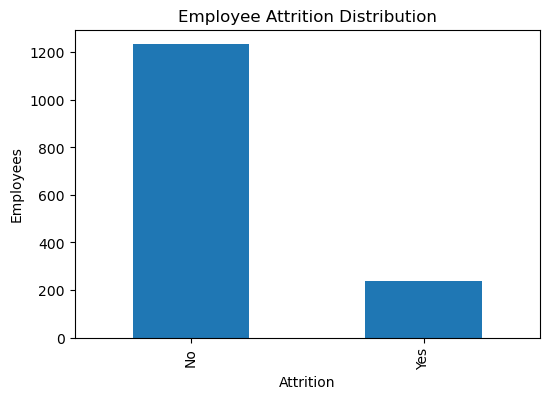

In [32]:
plt.figure(figsize=(6,4))

df['Attrition'].value_counts().plot(kind='bar')

plt.title("Employee Attrition Distribution")
plt.xlabel('Attrition')
plt.ylabel('Employees')

plt.show()

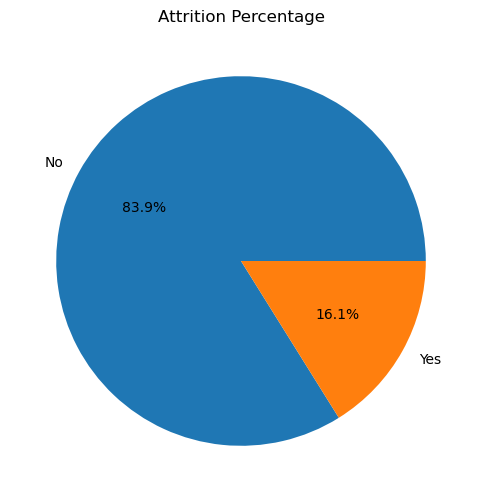

In [33]:
# Pie Chart
plt.figure(figsize=(6, 6))

df["Attrition"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Attrition Percentage")

plt.show()

In [38]:
# Categorical Feature Analysis
# Create a Feature List
categorical_features = [
'BusinessTravel',
 'Department',
 'EducationField',
 'Gender',
 'JobRole',
 'MaritalStatus',
 'OverTime']

In [39]:
for feature in categorical_features:
    print("=" * 60)
    print(feature)
    print("=" * 60)
    print(df[feature].value_counts())
    print()
    print(df[feature].value_counts(normalize=True) * 100)
    print("\n")

BusinessTravel
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

BusinessTravel
Travel_Rarely        70.952381
Travel_Frequently    18.843537
Non-Travel           10.204082
Name: proportion, dtype: float64


Department
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

Department
Research & Development    65.374150
Sales                     30.340136
Human Resources            4.285714
Name: proportion, dtype: float64


EducationField
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

EducationField
Life Sciences       41.224490
Medical             31.564626
Marketing           10.816327
Technical Degree     8.979592
Other                5.578231
Human Resources      1.836735
Name: proportion, dtype: float64


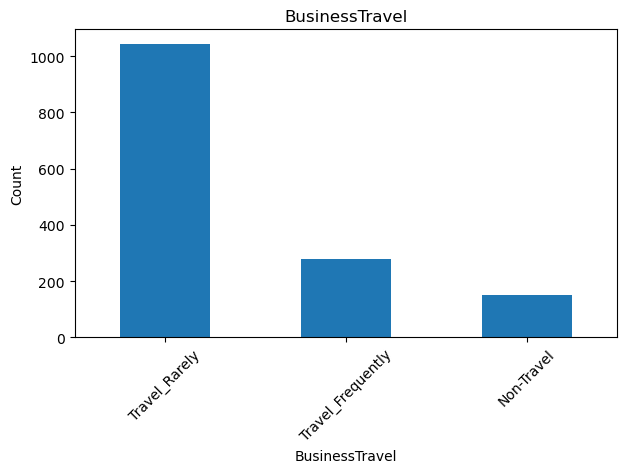

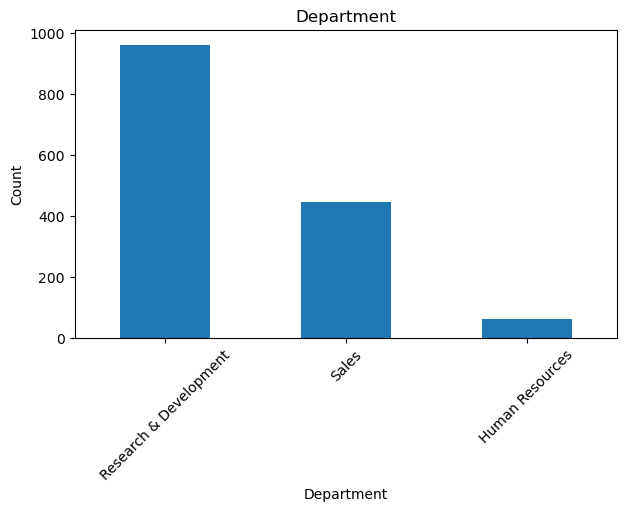

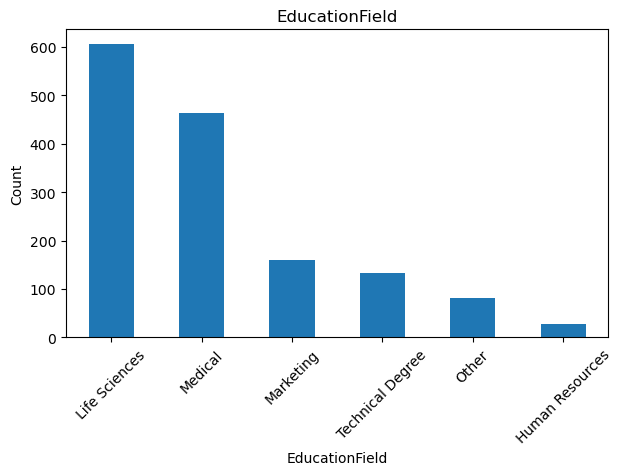

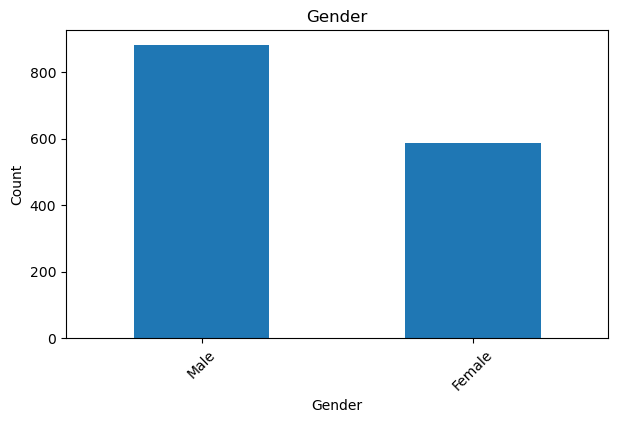

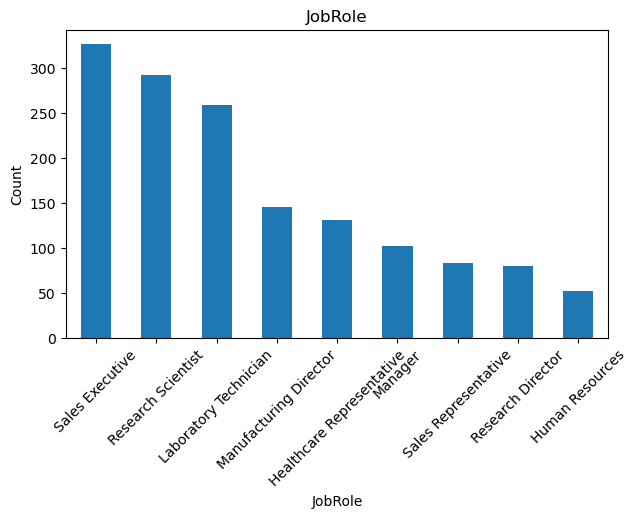

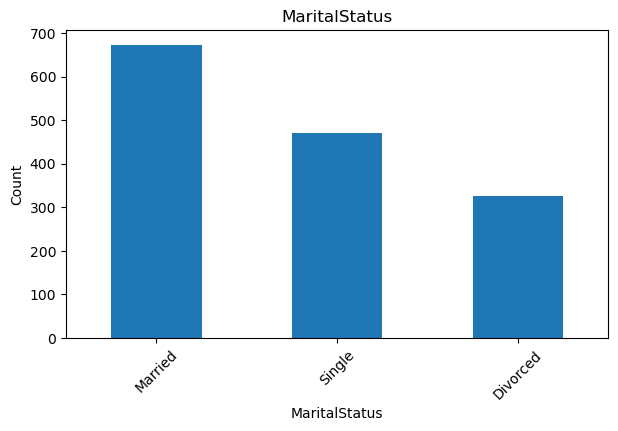

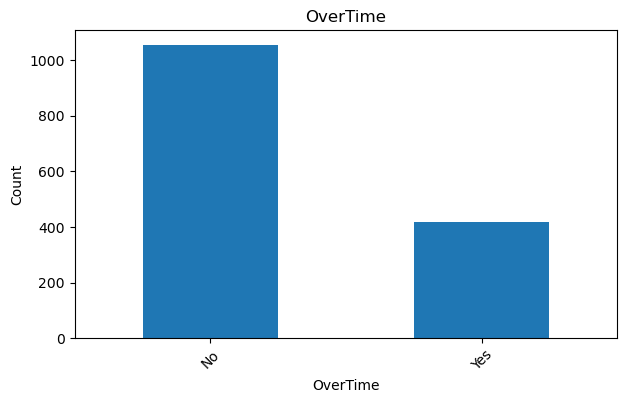

In [40]:
# Visualizing Categorical Features
for feature in categorical_features:
    plt.figure(figsize=(7, 4))
    df[feature].value_counts().plot(kind="bar")
    plt.title(feature)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

In [43]:
numerical_features = [
'Age',
 'DailyRate',
 'DistanceFromHome',
 'HourlyRate',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [44]:
df[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.0,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.00,29.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.0,66.0,83.75,100.0
MonthlyIncome,1470.0,6502.931293,4707.956783,1009.0,2911.0,4919.0,8379.00,19999.0
MonthlyRate,1470.0,14313.103401,7117.786044,2094.0,8047.0,14235.5,20461.50,26999.0
NumCompaniesWorked,1470.0,2.693197,2.498009,0.0,1.0,2.0,4.00,9.0
PercentSalaryHike,1470.0,15.209524,3.659938,11.0,12.0,14.0,18.00,25.0
TotalWorkingYears,1470.0,11.279592,7.780782,0.0,6.0,10.0,15.00,40.0
TrainingTimesLastYear,1470.0,2.799320,1.289271,0.0,2.0,3.0,3.00,6.0


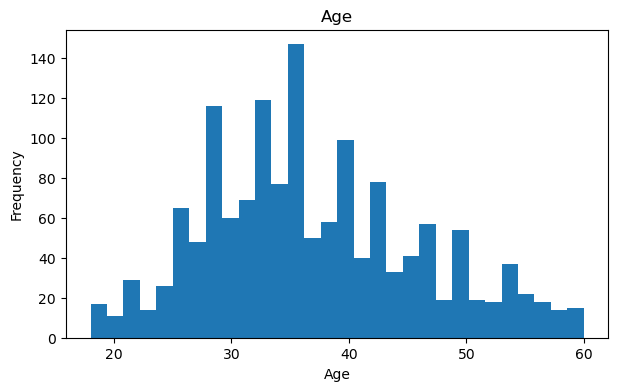

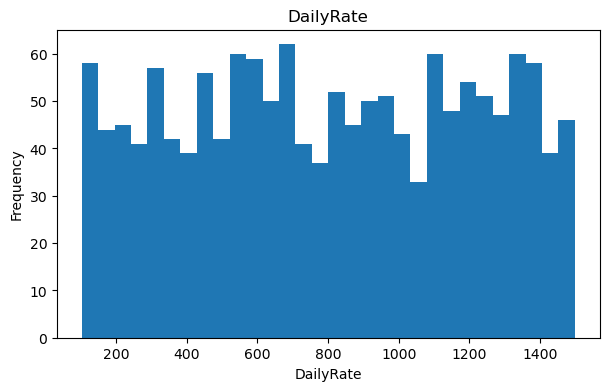

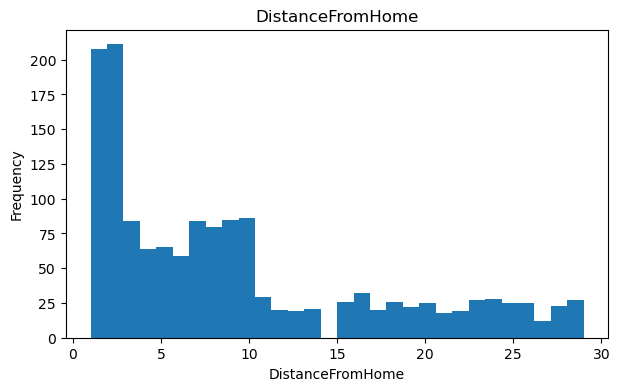

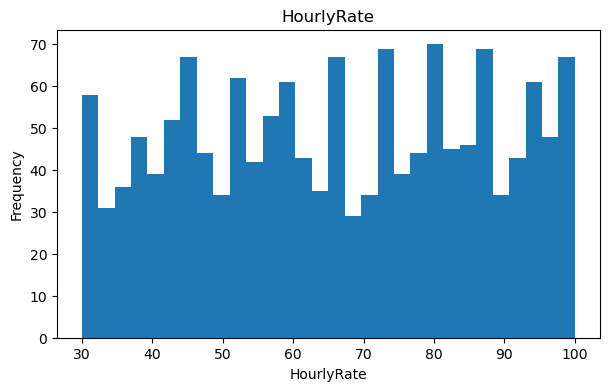

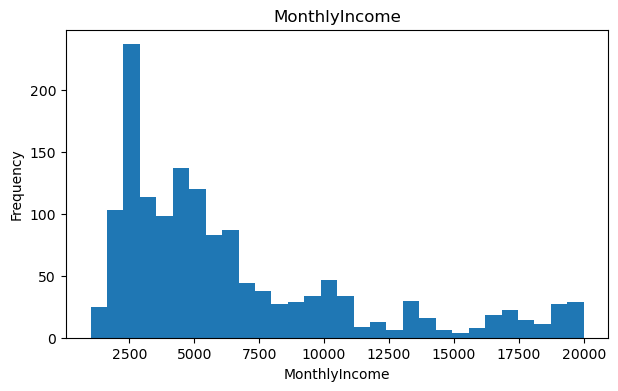

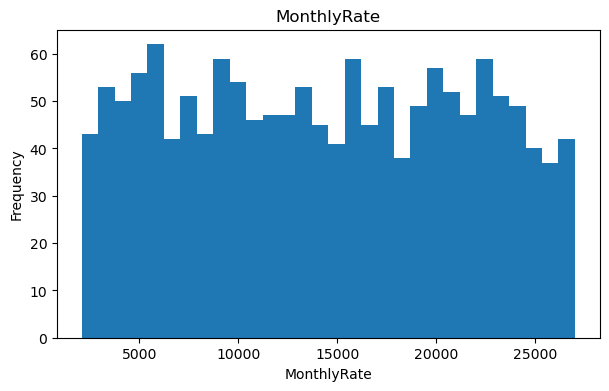

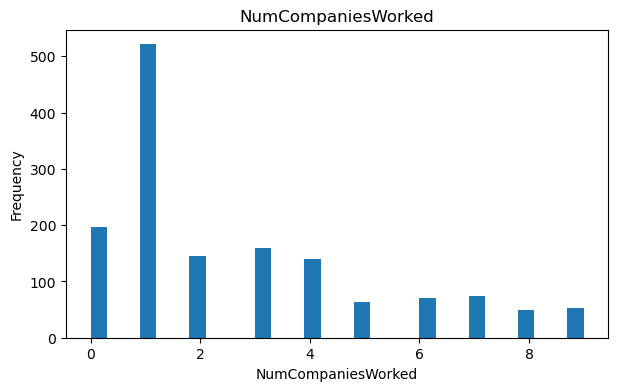

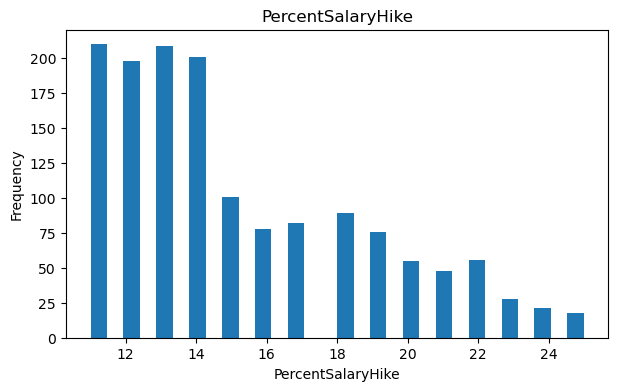

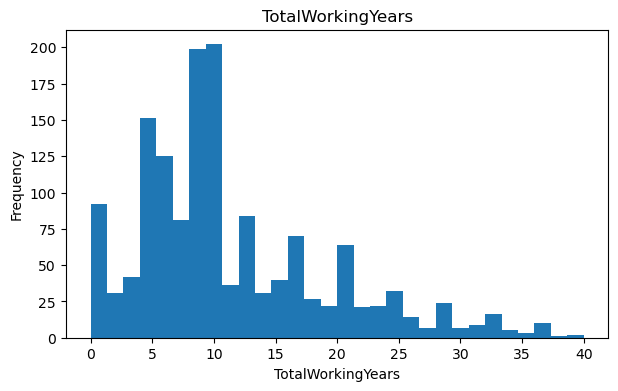

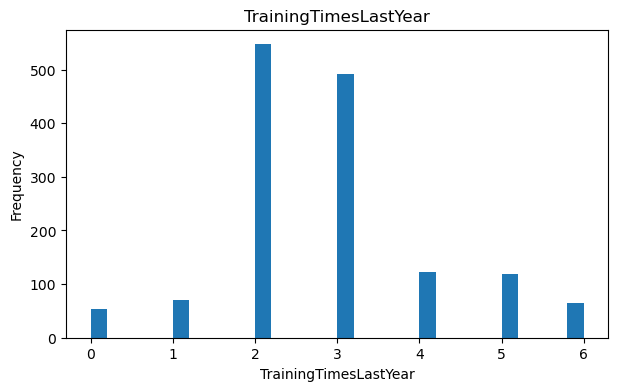

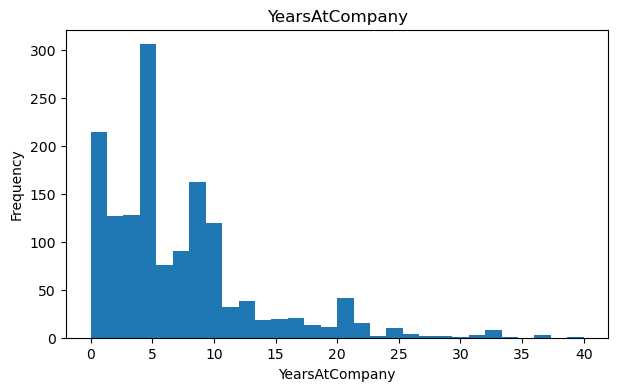

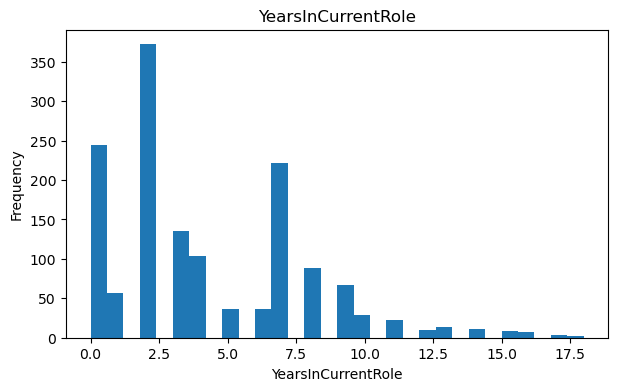

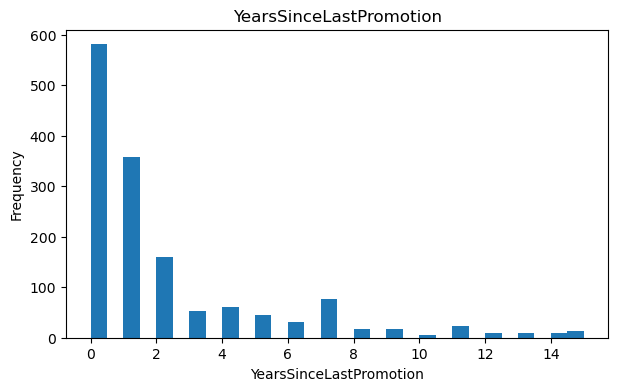

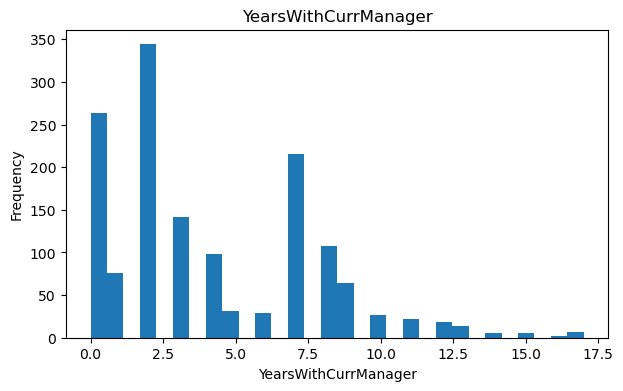

In [46]:
# Histograms
for feature in numerical_features:
    plt.figure(figsize=(7, 4))
    plt.hist(df[feature], bins=30)
    plt.title(feature)
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

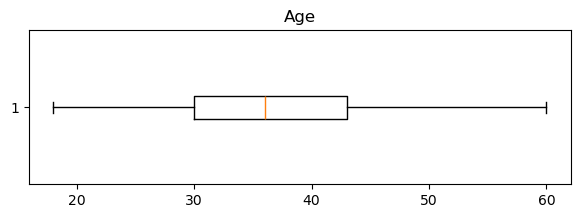

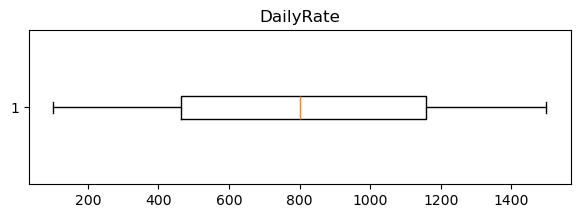

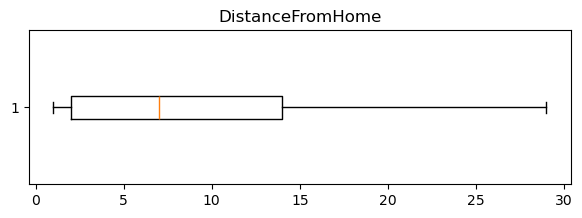

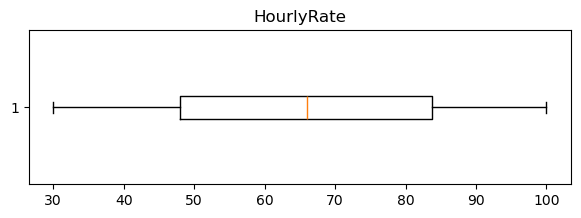

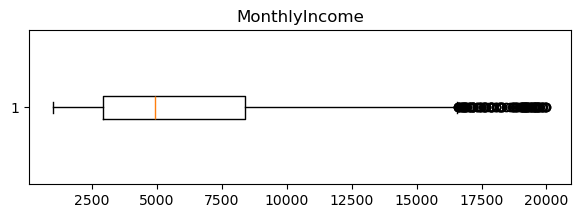

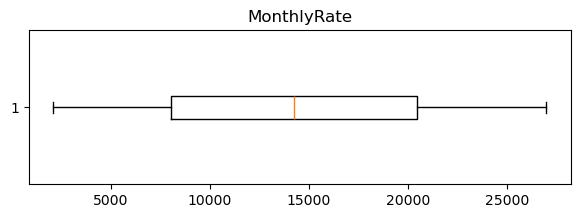

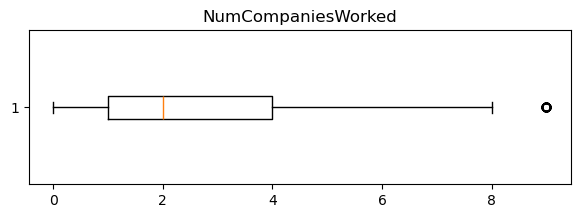

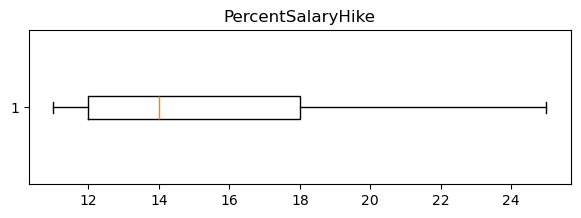

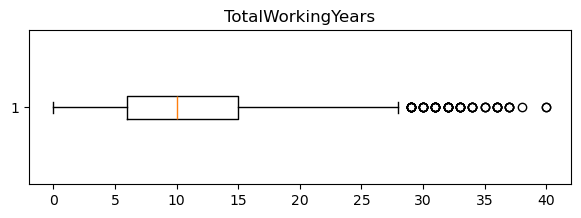

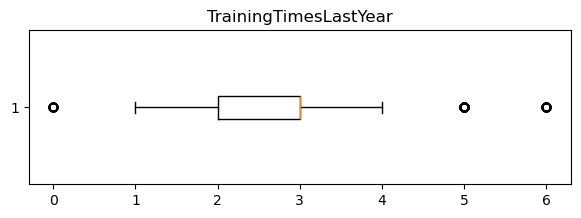

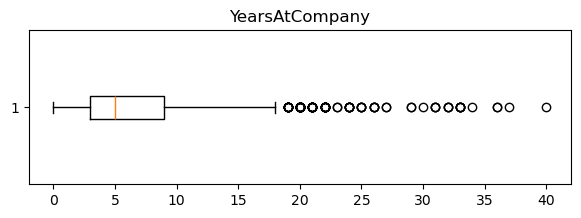

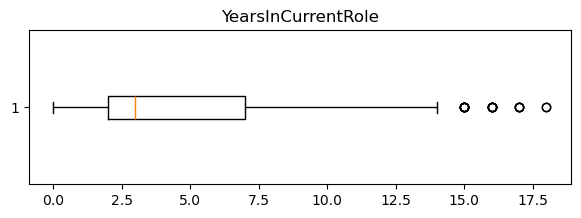

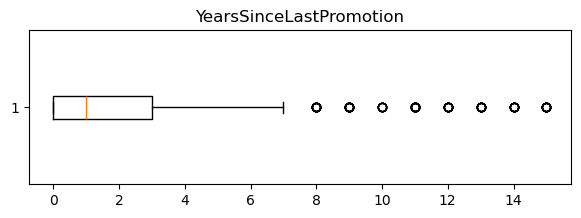

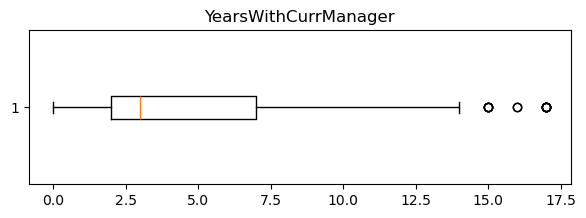

In [47]:
# BoxPlots
for feature in numerical_features:
    plt.figure(figsize=(7, 2))
    plt.boxplot(df[feature], vert=False)
    plt.title(feature)
    plt.show()

In [48]:
# Generate Crosstabs
for feature in categorical_features:
    print("=" * 70)
    print(feature)
    print("=" * 70)

    table = pd.crosstab(
        df[feature],
        df["Attrition"],
        normalize="index"
    ) * 100

    print(table.round(2))
    print("\n")

BusinessTravel
Attrition             No    Yes
BusinessTravel                 
Non-Travel         92.00   8.00
Travel_Frequently  75.09  24.91
Travel_Rarely      85.04  14.96


Department
Attrition                  No    Yes
Department                          
Human Resources         80.95  19.05
Research & Development  86.16  13.84
Sales                   79.37  20.63


EducationField
Attrition            No    Yes
EducationField                
Human Resources   74.07  25.93
Life Sciences     85.31  14.69
Marketing         77.99  22.01
Medical           86.42  13.58
Other             86.59  13.41
Technical Degree  75.76  24.24


Gender
Attrition     No    Yes
Gender                 
Female     85.20  14.80
Male       82.99  17.01


JobRole
Attrition                     No    Yes
JobRole                                
Healthcare Representative  93.13   6.87
Human Resources            76.92  23.08
Laboratory Technician      76.06  23.94
Manager                    95.10   4.90
Manufac

<Figure size 800x400 with 0 Axes>

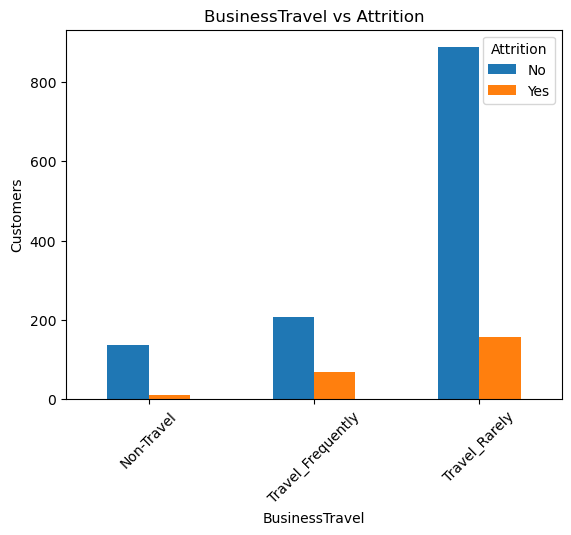

<Figure size 800x400 with 0 Axes>

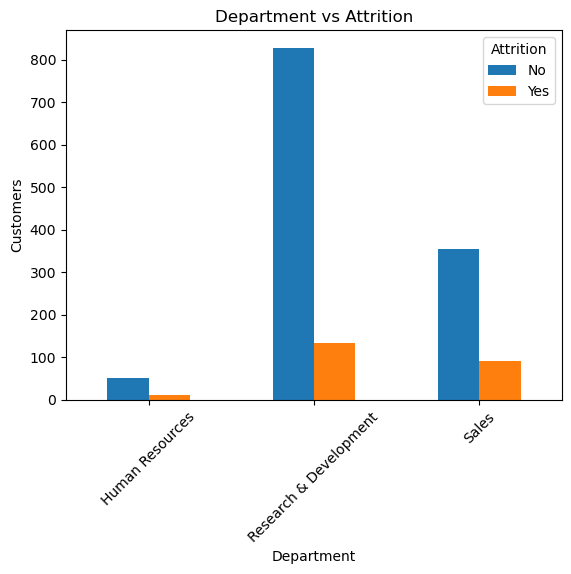

<Figure size 800x400 with 0 Axes>

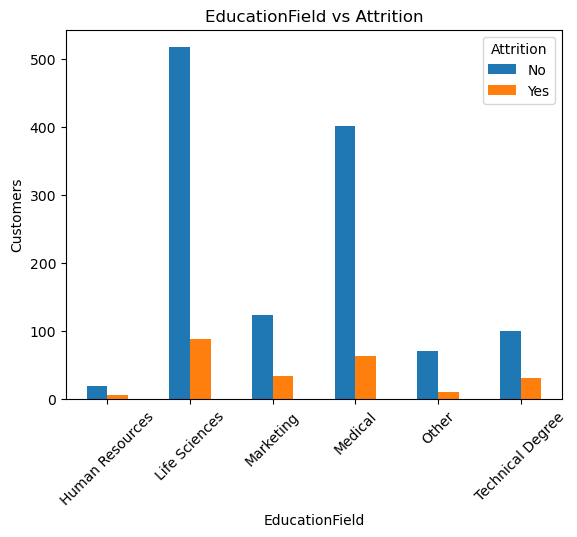

<Figure size 800x400 with 0 Axes>

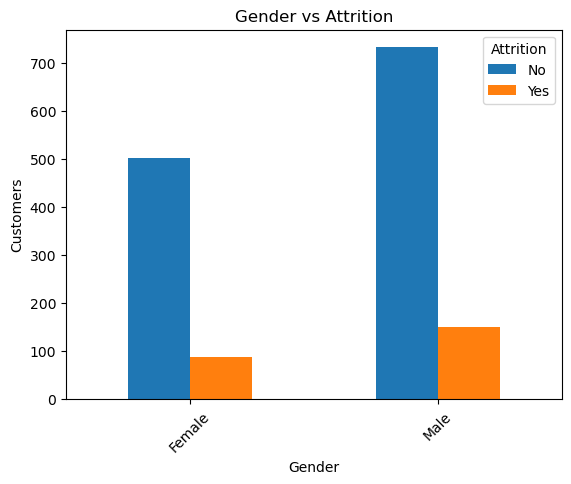

<Figure size 800x400 with 0 Axes>

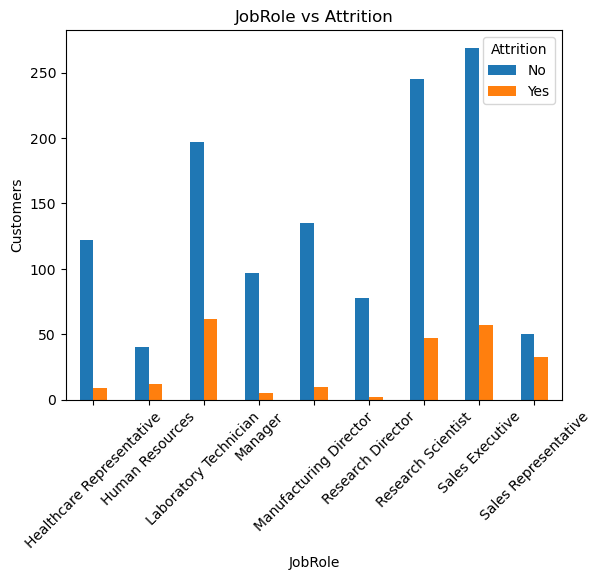

<Figure size 800x400 with 0 Axes>

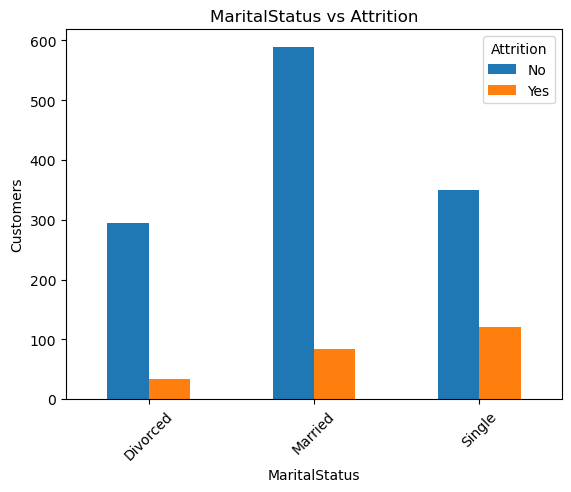

<Figure size 800x400 with 0 Axes>

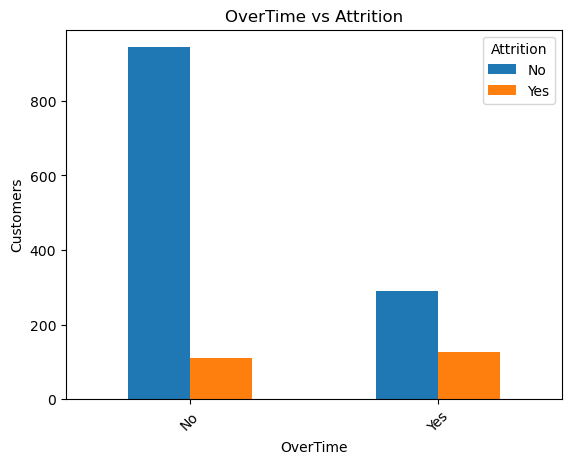

In [50]:
for feature in categorical_features:
    plt.figure(figsize=(8, 4))
    pd.crosstab(df[feature], df["Attrition"]).plot(kind="bar")
    plt.title(feature + " vs Attrition")
    plt.ylabel("Customers")
    plt.xticks(rotation=45)
    plt.show()

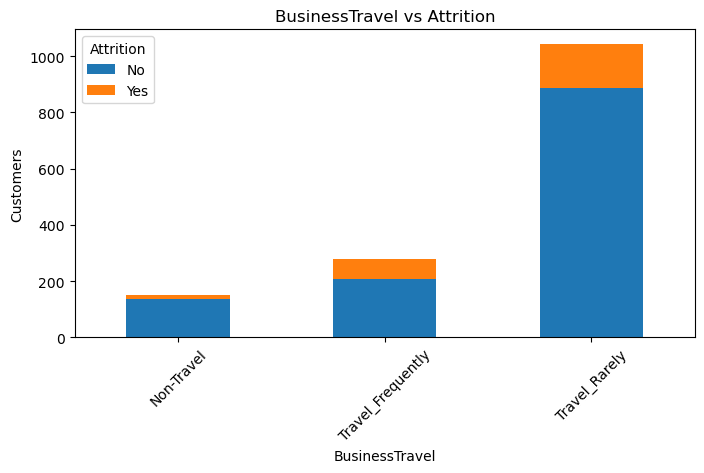

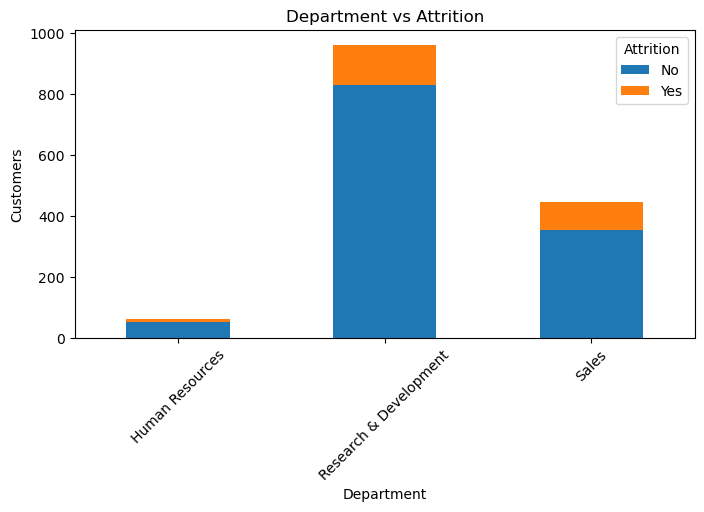

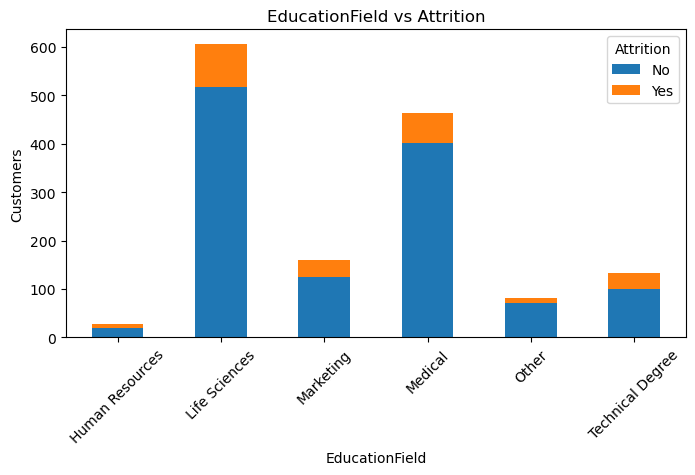

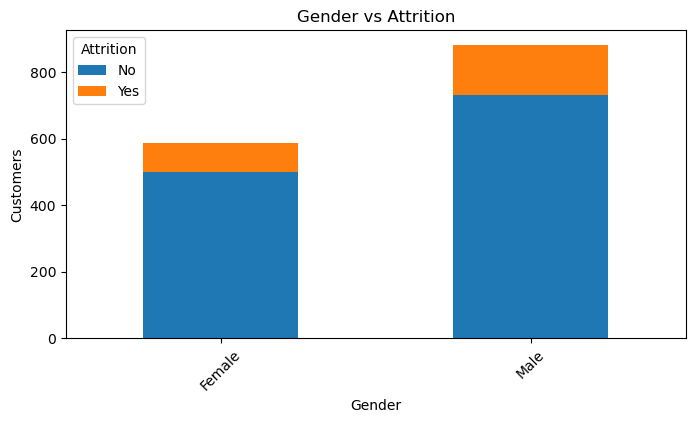

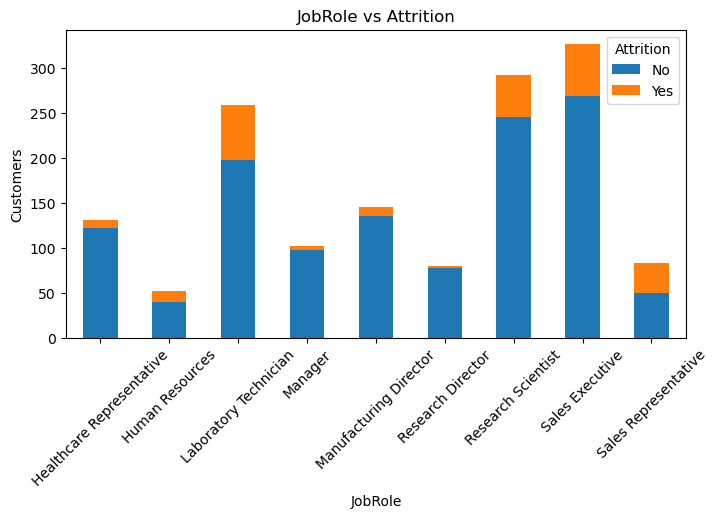

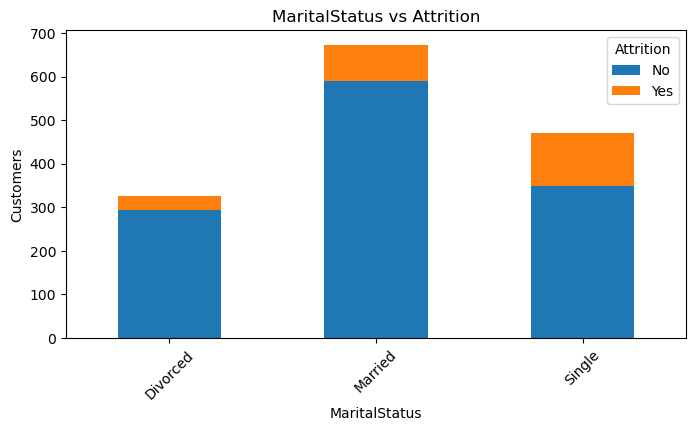

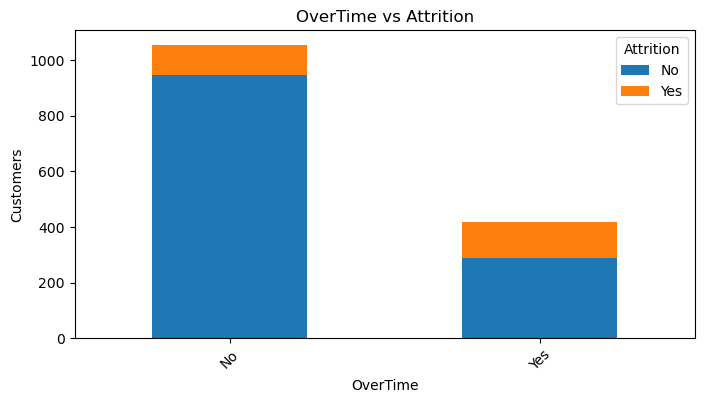

In [52]:
for feature in categorical_features:
    pd.crosstab(df[feature], df["Attrition"]).plot(
        kind="bar",
        stacked=True,
        figsize=(8, 4)
    )
    plt.title(feature + " vs Attrition")
    plt.ylabel("Customers")
    plt.xticks(rotation=45)
    plt.show()

In [53]:
for feature in numerical_features:
    print("=" * 60)
    print(feature)
    print("=" * 60)
    print(df.groupby("Attrition")[feature].describe())
    print("\n")

Age
            count       mean      std   min   25%   50%   75%   max
Attrition                                                          
No         1233.0  37.561233  8.88836  18.0  31.0  36.0  43.0  60.0
Yes         237.0  33.607595  9.68935  18.0  28.0  32.0  39.0  58.0


DailyRate
            count        mean         std    min    25%    50%     75%     max
Attrition                                                                     
No         1233.0  812.504461  403.208379  102.0  477.0  817.0  1176.0  1499.0
Yes         237.0  750.362869  401.899519  103.0  408.0  699.0  1092.0  1496.0


DistanceFromHome
            count       mean       std  min  25%  50%   75%   max
Attrition                                                        
No         1233.0   8.915653  8.012633  1.0  2.0  7.0  13.0  29.0
Yes         237.0  10.632911  8.452525  1.0  3.0  9.0  17.0  29.0


HourlyRate
            count       mean        std   min   25%   50%   75%    max
Attrition                    

<Figure size 700x400 with 0 Axes>

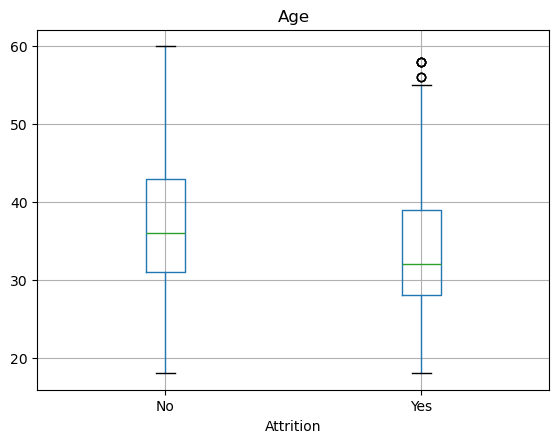

<Figure size 700x400 with 0 Axes>

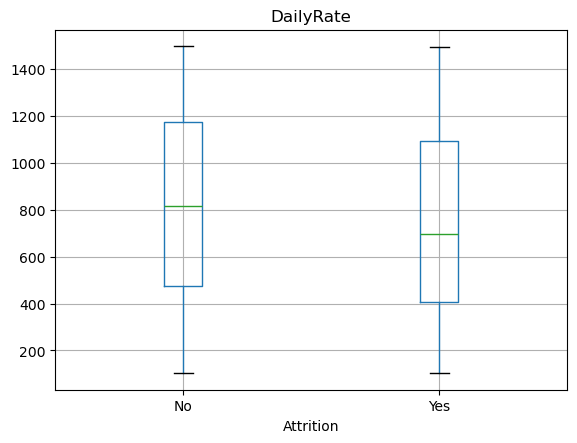

<Figure size 700x400 with 0 Axes>

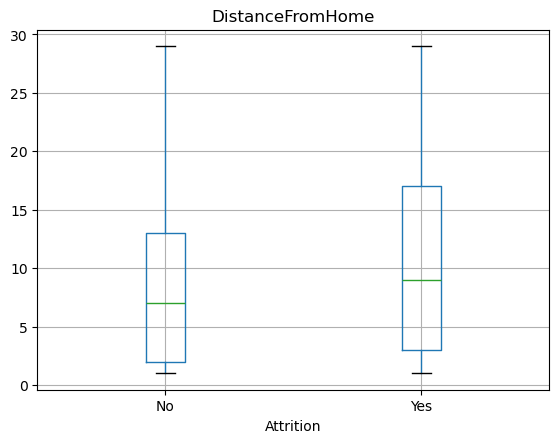

<Figure size 700x400 with 0 Axes>

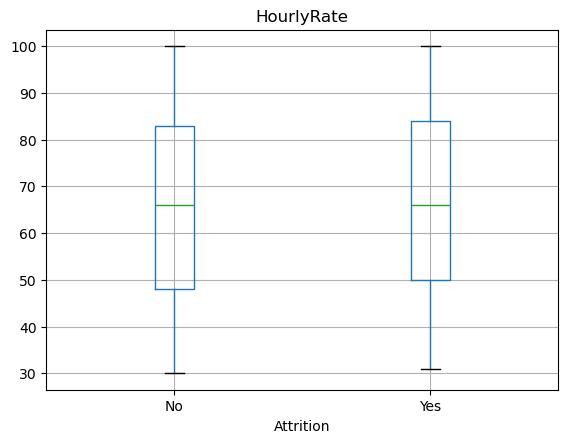

<Figure size 700x400 with 0 Axes>

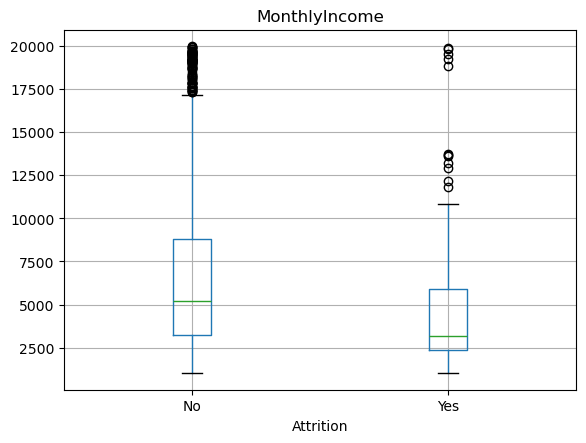

<Figure size 700x400 with 0 Axes>

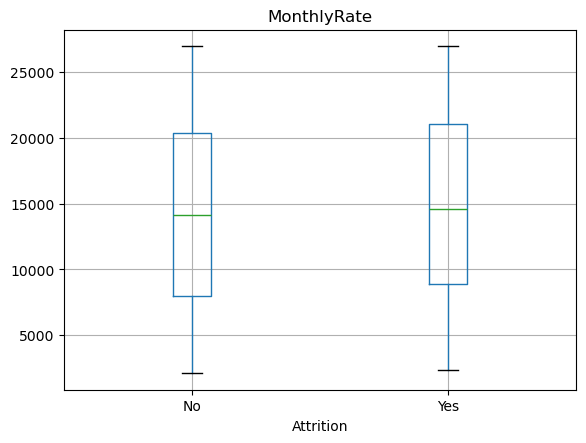

<Figure size 700x400 with 0 Axes>

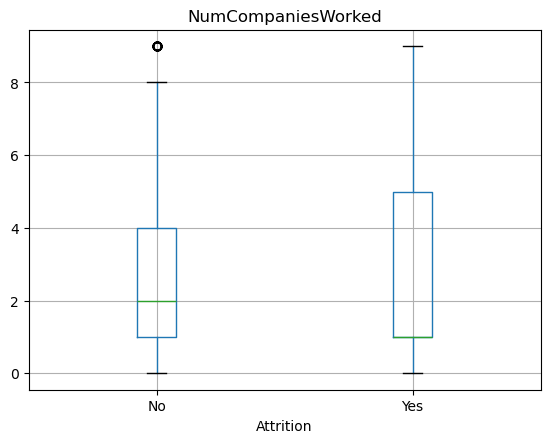

<Figure size 700x400 with 0 Axes>

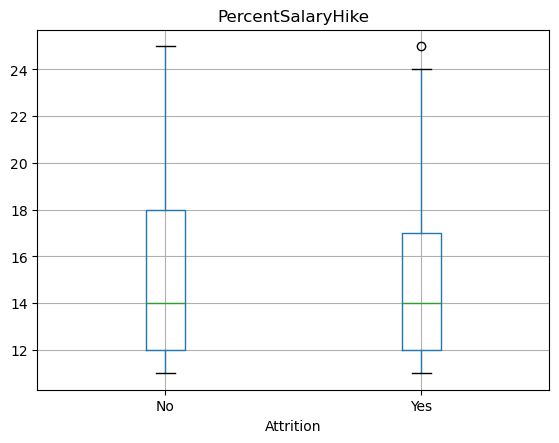

<Figure size 700x400 with 0 Axes>

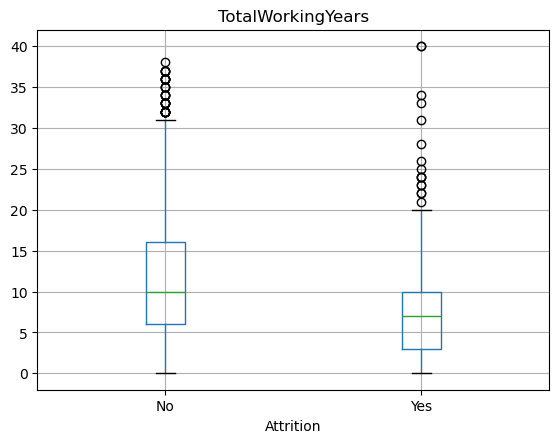

<Figure size 700x400 with 0 Axes>

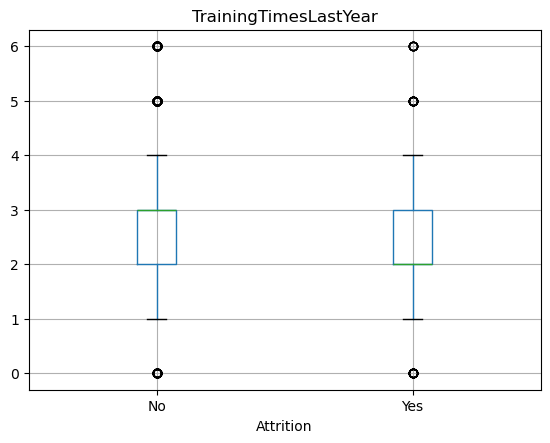

<Figure size 700x400 with 0 Axes>

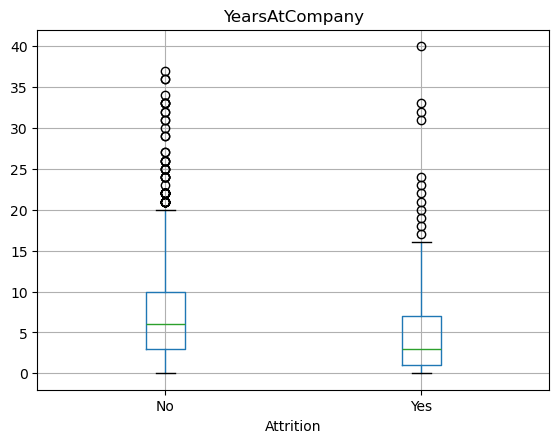

<Figure size 700x400 with 0 Axes>

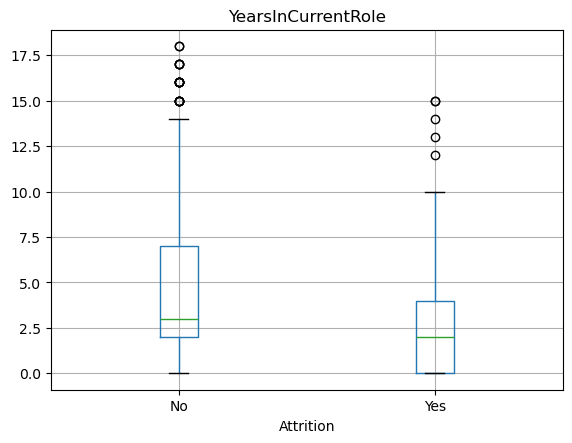

<Figure size 700x400 with 0 Axes>

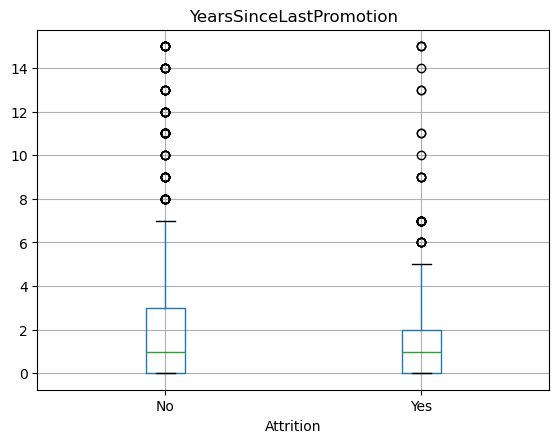

<Figure size 700x400 with 0 Axes>

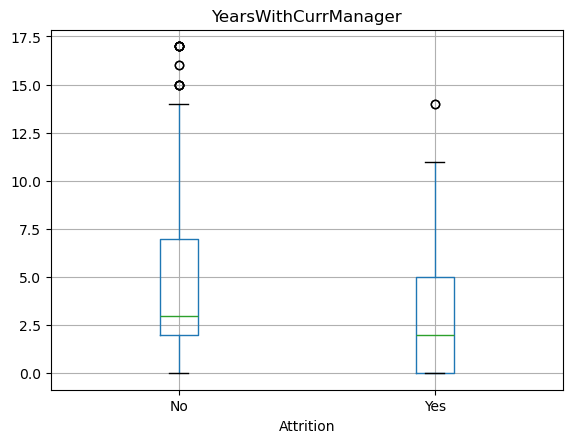

In [55]:
# BoxPlots
for feature in numerical_features:
    plt.figure(figsize=(7, 4))
    df.boxplot(column=feature, by="Attrition")
    plt.title(feature)
    plt.suptitle("")
    plt.show()

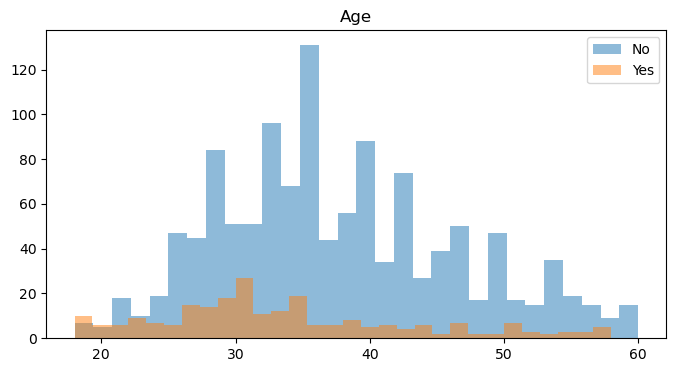

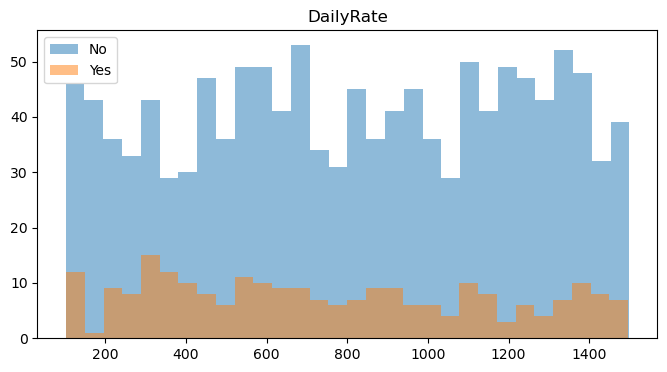

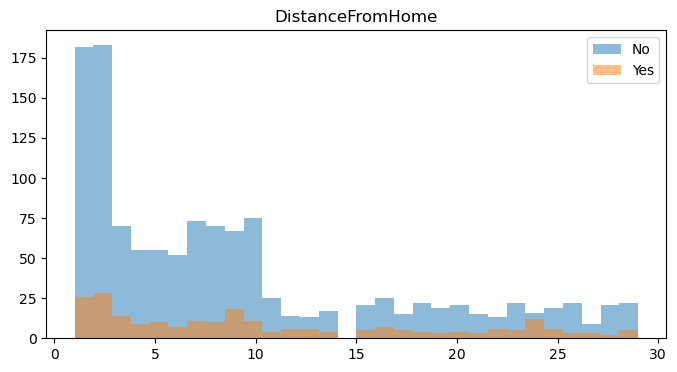

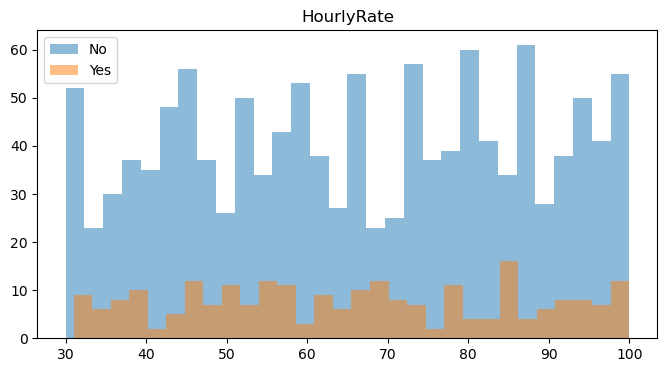

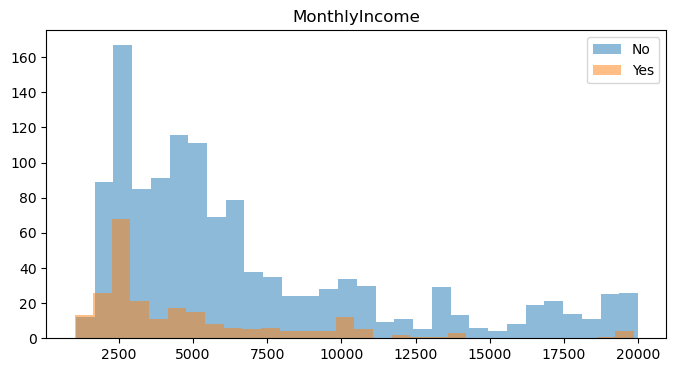

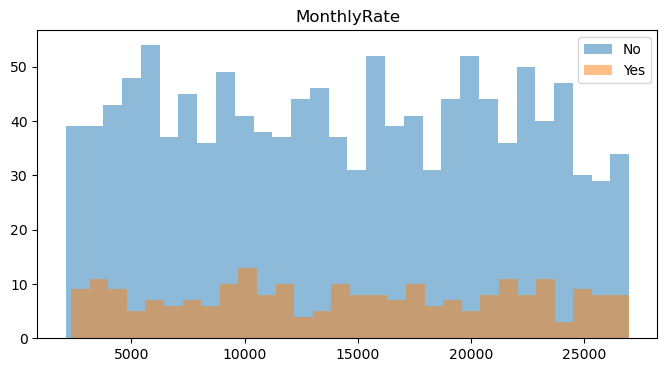

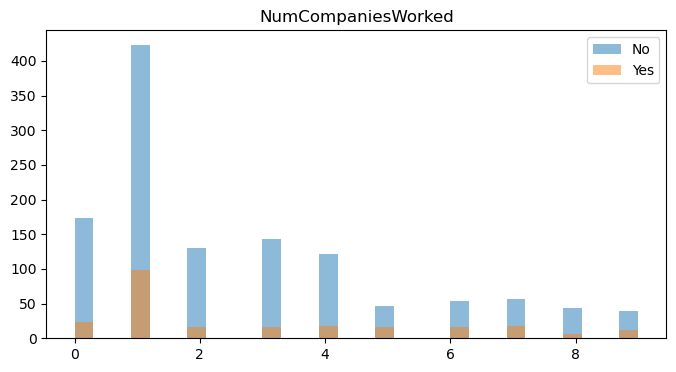

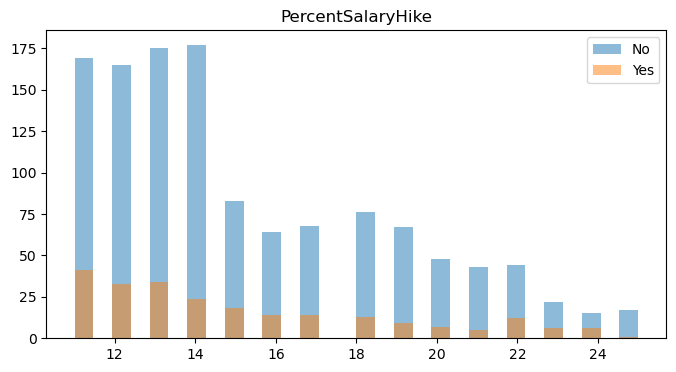

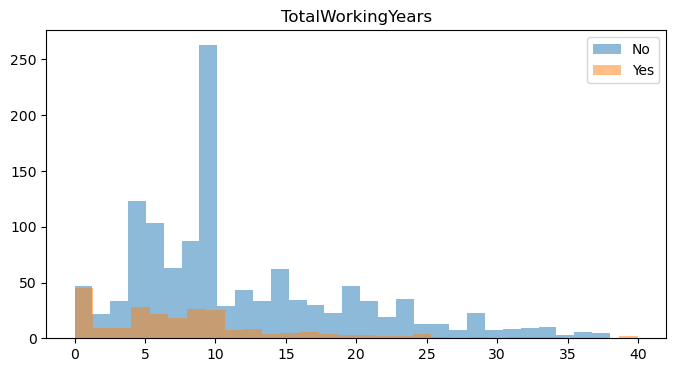

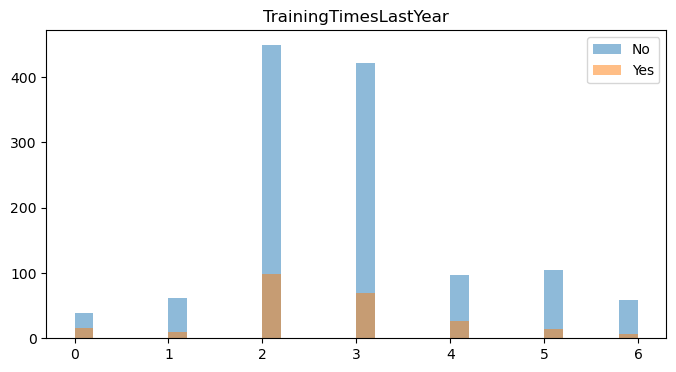

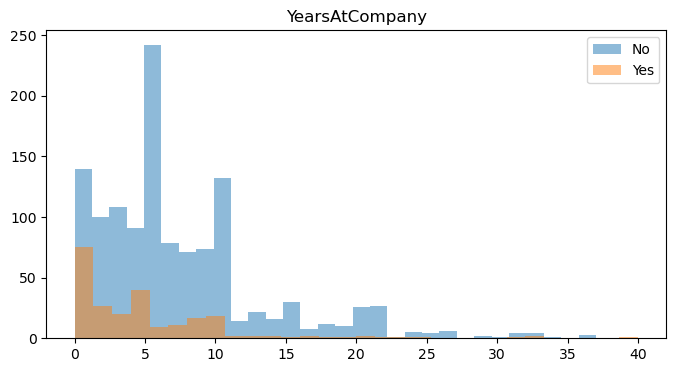

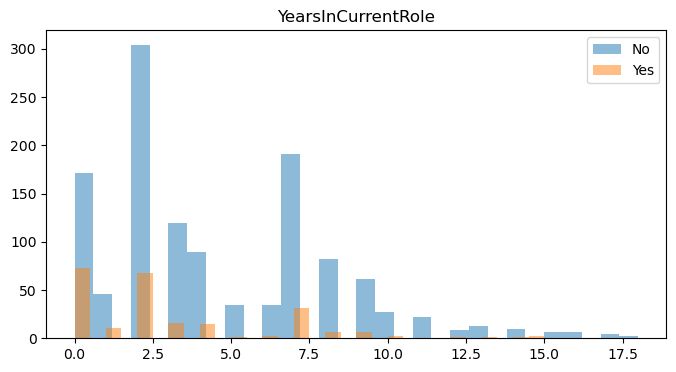

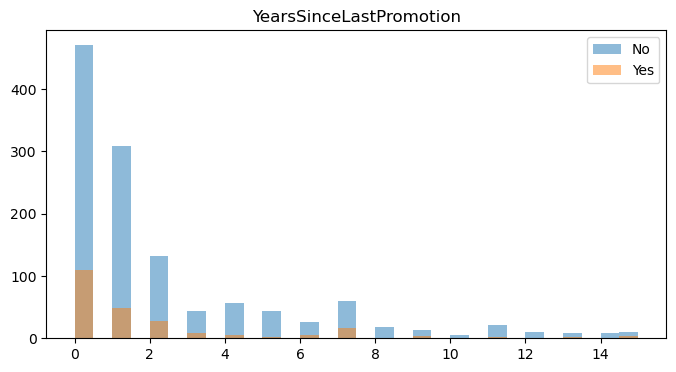

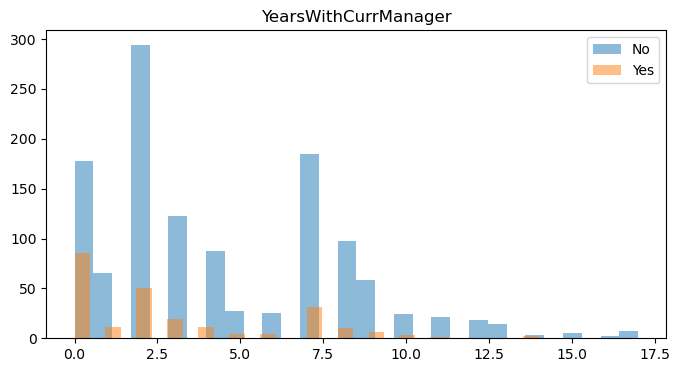

In [56]:
# Histogram
for feature in numerical_features:
    plt.figure(figsize=(8, 4))

    plt.hist(
        df[df["Attrition"] == "No"][feature],
        alpha=0.5,
        bins=30,
        label="No"
    )
    plt.hist(
        df[df["Attrition"] == "Yes"][feature],
        alpha=0.5,
        bins=30,
        label="Yes"
    )

    plt.legend()
    plt.title(feature)
    plt.show()

In [57]:
correlation_matrix = df[numerical_features].corr()

correlation_matrix

,Age,DailyRate,DistanceFromHome,HourlyRate,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000,0.010661,-0.001686,0.024287,0.497855,0.028051,0.299635,0.003634,0.680381,-0.019621,0.311309,0.212901,0.216513,0.202089
DailyRate,0.010661,1.000000,-0.004985,0.023381,0.007707,-0.032182,0.038153,0.022704,0.014515,0.002453,-0.034055,0.009932,-0.033229,-0.026363
DistanceFromHome,-0.001686,-0.004985,1.000000,0.031131,-0.017014,0.027473,-0.029251,0.040235,0.004628,-0.036942,0.009508,0.018845,0.010029,0.014406
HourlyRate,0.024287,0.023381,0.031131,1.000000,-0.015794,-0.015297,0.022157,-0.009062,-0.002334,-0.008548,-0.019582,-0.024106,-0.026716,-0.020123
MonthlyIncome,0.497855,0.007707,-0.017014,-0.015794,1.000000,0.034814,0.149515,-0.027269,0.772893,-0.021736,0.514285,0.363818,0.344978,0.344079
MonthlyRate,0.028051,-0.032182,0.027473,-0.015297,0.034814,1.000000,0.017521,-0.006429,0.026442,0.001467,-0.023655,-0.012815,0.001567,-0.036746
NumCompaniesWorked,0.299635,0.038153,-0.029251,0.022157,0.149515,0.017521,1.000000,-0.010238,0.237639,-0.066054,-0.118421,-0.090754,-0.036814,-0.110319
PercentSalaryHike,0.003634,0.022704,0.040235,-0.009062,-0.027269,-0.006429,-0.010238,1.000000,-0.020608,-0.005221,-0.035991,-0.001520,-0.022154,-0.011985
TotalWorkingYears,0.680381,0.014515,0.004628,-0.002334,0.772893,0.026442,0.237639,-0.020608,1.000000,-0.035662,0.628133,0.460365,0.404858,0.459188
TrainingTimesLastYear,-0.019621,0.002453,-0.036942,-0.008548,-0.021736,0.001467,-0.066054,-0.005221,-0.035662,1.000000,0.003569,-0.005738,-0.002067,-0.004096


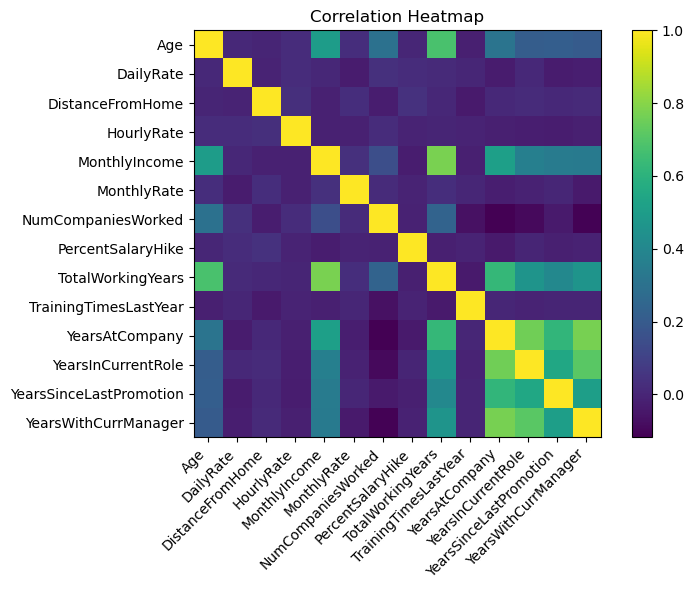

In [58]:
plt.figure(figsize=(8,6))

plt.imshow(correlation_matrix, interpolation="nearest")

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

In [62]:
threshold = 0.75

corr = correlation_matrix.abs()

high_correlation = [
    (corr.columns[i], corr.columns[j], corr.iloc[i, j])
    for i in range(len(corr.columns))
    for j in range(i)
    if corr.iloc[i, j] > threshold
]

high_correlation

[('TotalWorkingYears', 'MonthlyIncome', np.float64(0.7728932462543574)),
 ('YearsInCurrentRole', 'YearsAtCompany', np.float64(0.7587537366134619)),
 ('YearsWithCurrManager', 'YearsAtCompany', np.float64(0.7692124251007031))]

## Key Takeaways

- The target is moderately imbalanced (~16% attrition) - use Precision, Recall, and F1-score.
- `EmployeeNumber`, `EmployeeCount`, `Over18`, `StandardHours` are identifiers/constants and are dropped downstream.